# Treinamento Q-Learning — Decisão Financeira

Notebook de treinamento do agente Q-Learning para o problema de portfólio simplificado (T2).  
O loop varia **learning_rate** × **epsilon_decay_type** e armazena os resultados para análise posterior.

## 1 — Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Imports do projeto
from env.env import StockMarketEnv
from agents.q_learning import QLearningAgent
from agents.sarsa import SARSAAgent

from datetime import datetime

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)

In [ ]:
NUM_EPISODES = 5000

# ── Parâmetros variáveis ──────────────────────────────────────────────
AGENT_TYPES = ["Q-Learning", "SARSA"]
LEARNING_RATES      = [0.0001, 0.0005, 0.001, 0.005, 0.01]
EPSILON_DECAY_TYPES = ["constant", "linear", "exponential"]
GAMMA_VALUES        = [0.8, 0.9, 0.95, 0.99]

# ── Caminhos dos dados ────────────────────────────────────────────────
TRAIN_DATA_PATH = "data/amzn_transformed_train.csv"
TEST_DATA_PATH  = "data/amzn_transformed_test.csv"
total_combos = len(AGENT_TYPES) * len(LEARNING_RATES) * len(EPSILON_DECAY_TYPES) * len(GAMMA_VALUES)
print(f"Configurações: {len(AGENT_TYPES)} Agentes × {len(LEARNING_RATES)} LRs × {len(EPSILON_DECAY_TYPES)} Decays × {len(GAMMA_VALUES)} Gammas = {total_combos} combinações")

Configurações: 5 LRs × 3 decay types = 15 combinações


## 2 — Funções Auxiliares

In [ ]:
def train_agent(env, agent, n_episodes, is_sarsa):
    """
    Treina os agente Q-learning ou SARSA por n_episodes.
    
    Retorna um dicionário com métricas por episódio:
        - episode_rewards:  lista de recompensa acumulada por episódio
        - episode_epsilons: lista de epsilon ao final de cada episódio
        - episode_steps:    lista de número de steps por episódio
    """
    episode_rewards  = []
    episode_epsilons = []
    episode_steps    = []

    for ep in range(n_episodes):
        state = env.reset()

        # Se for SARSA, a primeira ação deve ser escolhida antes do loop
        if is_sarsa:
            action = agent.choose_action(state, training=True)

        total_reward = 0.0
        steps = 0
        done = False

        while not done:
            # Se for Q-Learning, a ação atual é escolhida no início da iteração
            if not is_sarsa:
                action = agent.choose_action(state, training=True)

            next_state, reward, done = env.step(action)

            # Ramificação do Update
            if is_sarsa:
                # SARSA: escolhe a próxima ação agora, atualiza, e a guarda para o próximo loop
                next_action = agent.choose_action(next_state, training=True)
                agent.update(state, action, reward, next_state, next_action, done)
                
                # A ação atual passa a ser a próxima ação que já foi decidida
                action = next_action 
            else:
                # Q-Learning: o update clássico não precisa saber qual a próxima ação real
                agent.update(state, action, reward, next_state, done)

            state = next_state
            total_reward += reward
            steps += 1

        # Atualiza epsilon ao final do episódio
        agent.update_epsilon(ep)

        episode_rewards.append(total_reward)
        episode_epsilons.append(agent.epsilon)
        episode_steps.append(steps)

        if ep % 50 == 0: 
            print(f"Ep: {ep}/{n_episodes}")

    return {
        "episode_rewards":  episode_rewards,
        "episode_epsilons": episode_epsilons,
        "episode_steps":    episode_steps,
        }

def evaluate_agent(data_path, agent):
    """
    Avalia o agente de forma greedy (sem exploração) em um dataset.
    
    Retorna:
        - total_reward: recompensa acumulada total
        - step_rewards: lista de recompensa por step
        - positions:    lista de posições ao longo dos steps
    """
    env = StockMarketEnv(data_path)
    state = env.reset()

    total_reward = 0.0
    step_rewards = []
    positions    = []
    done = False

    while not done:
        action = agent.choose_action(state, training=False)
        next_state, reward, done = env.step(action)

        total_reward += reward
        step_rewards.append(reward)
        positions.append(env.position)

        state = next_state

    return {
        "total_reward": total_reward,
        "step_rewards": step_rewards,
        "positions":    positions,
        }

In [4]:
inicio = datetime.now()
print(f"Início: {inicio.strftime('%Y-%m-%d %H:%M:%S')}")

Início: 2026-04-25 19:50:01


In [ ]:
# Dicionário para armazenar todos os resultados
# Chave: (agent_type, decay_type, lr) → valor: dict com métricas + agente treinado
results = {}
combo_idx = 0

for agent_type in AGENT_TYPES:
    for decay_type in EPSILON_DECAY_TYPES:
        for lr in LEARNING_RATES:
            for gamma in GAMMA_VALUES:
                combo_idx += 1
                print(f"\n[{combo_idx}/{total_combos}] Agente={agent_type} decay={decay_type}, lr={lr}, gamma={gamma}")

                # Cria environment e agente
                env = StockMarketEnv(TRAIN_DATA_PATH)

                # Instancia o agente correto dependendo do loop atual
                if agent_type == "Q-Learning":
                    agent = QLearningAgent(
                        env=env,
                        learning_rate=lr,
                        gamma=gamma,
                        epsilon_decay_type=decay_type,
                    )
                    is_sarsa_flag = False
                else:
                    agent = SARSAAgent(
                        env=env,
                        learning_rate=lr,
                        gamma=gamma,
                        epsilon_decay_type=decay_type,
                    )
                    is_sarsa_flag = True
                
                # Treina
                metrics = train_agent(env, agent, NUM_EPISODES, is_sarsa_flag)

                # Armazena resultados
                key = (agent_type, decay_type, lr, gamma)
                results[key] = {
                    "metrics": metrics,
                    "agent":   agent,
                }

                # Resumo rápido
                mean_last_100 = np.mean(metrics["episode_rewards"][-100:])
                print(f"  → Reward médio (últimos 100 eps): {mean_last_100:.4f}")
                print(f"  → Epsilon final: {metrics['episode_epsilons'][-1]:.4f}")
                print(f"  → Estados na Q-table: {agent.q_table.shape}")

print("\n✅ Treinamento concluído para todas as combinações!")


[1/15] decay=constant, lr=0.0001
Ep: 0/5000
Ep: 50/5000
Ep: 100/5000
Ep: 150/5000
Ep: 200/5000
Ep: 250/5000
Ep: 300/5000
Ep: 350/5000
Ep: 400/5000
Ep: 450/5000
Ep: 500/5000
Ep: 550/5000
Ep: 600/5000
Ep: 650/5000
Ep: 700/5000
Ep: 750/5000
Ep: 800/5000
Ep: 850/5000
Ep: 900/5000
Ep: 950/5000
Ep: 1000/5000
Ep: 1050/5000
Ep: 1100/5000
Ep: 1150/5000
Ep: 1200/5000
Ep: 1250/5000
Ep: 1300/5000
Ep: 1350/5000
Ep: 1400/5000
Ep: 1450/5000
Ep: 1500/5000
Ep: 1550/5000
Ep: 1600/5000
Ep: 1650/5000
Ep: 1700/5000
Ep: 1750/5000
Ep: 1800/5000
Ep: 1850/5000
Ep: 1900/5000
Ep: 1950/5000
Ep: 2000/5000
Ep: 2050/5000
Ep: 2100/5000
Ep: 2150/5000
Ep: 2200/5000
Ep: 2250/5000
Ep: 2300/5000
Ep: 2350/5000
Ep: 2400/5000
Ep: 2450/5000
Ep: 2500/5000
Ep: 2550/5000
Ep: 2600/5000
Ep: 2650/5000
Ep: 2700/5000
Ep: 2750/5000
Ep: 2800/5000
Ep: 2850/5000
Ep: 2900/5000
Ep: 2950/5000
Ep: 3000/5000
Ep: 3050/5000
Ep: 3100/5000
Ep: 3150/5000
Ep: 3200/5000
Ep: 3250/5000
Ep: 3300/5000
Ep: 3350/5000
Ep: 3400/5000
Ep: 3450/5000
Ep: 3500/

In [6]:
fim = datetime.now()
print(f"Fim: {fim.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Duração: {fim - inicio}")

Fim: 2026-04-25 20:42:49
Duração: 0:52:47.371444


## 4 — Visualizações

### 4.1 — Curvas de Aprendizado (Reward Acumulado por Episódio)

Um subplot por tipo de decaimento epsilon, com uma curva por learning rate.

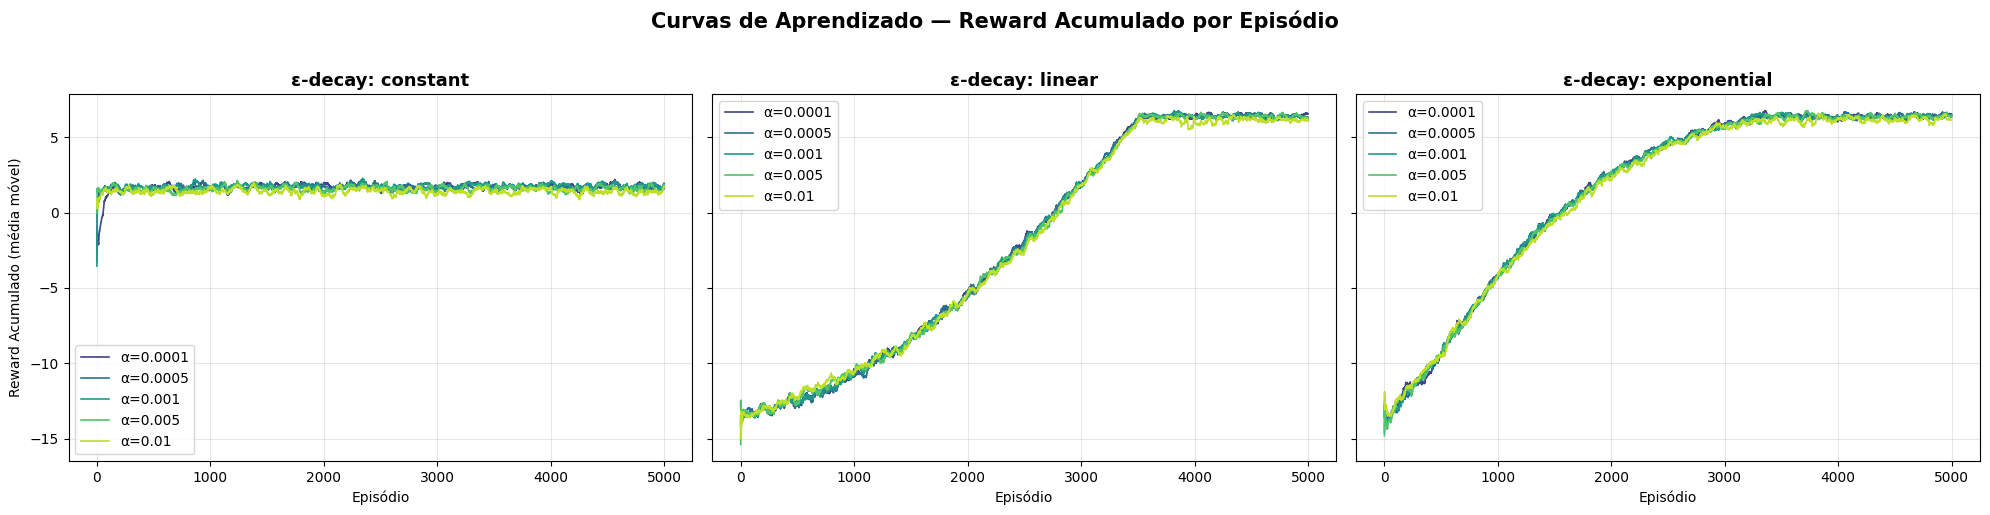

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(LEARNING_RATES)))
SMOOTH_WINDOW = 50  # janela para média móvel

# Dicionário para estilos de linha diferenciando visualmente os agentes
line_styles = {"Q-Learning": "-", "SARSA": "--"}
for ax_idx, decay_type in enumerate(EPSILON_DECAY_TYPES):
    ax = axes[ax_idx]
    ax.set_title(f"ε-decay: {decay_type}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Episódio")
    if ax_idx == 0:
        ax.set_ylabel("Reward Acumulado (média móvel)")

    # Iteramos sobre os agentes além dos learning rates e dos gammas
    for agent_type in AGENT_TYPES:
        for lr_idx, lr in enumerate(LEARNING_RATES):
            for gamma in GAMMA_VALUES:
                key = (agent_type, decay_type, lr, gamma)
                
                # Garantia caso alguma combinação não tenha sido treinada
                if key not in results:
                    continue

                rewards = results[key]["metrics"]["episode_rewards"]
                # Média móvel para suavizar
                smoothed = pd.Series(rewards).rolling(window=SMOOTH_WINDOW, min_periods=1).mean()
                ax.plot(smoothed, 
                        label=f"{agent_type} (α={lr})", 
                        color=colors[lr_idx], 
                        linestyle=line_styles[agent_type],
                        linewidth=1.5,
                        alpha = 0.85)

    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle("Curvas de Aprendizado — Reward Acumulado por Episódio: Q-Learning vs SARSA", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 4.2 — Comparação entre Estratégias de Exploração

Para cada learning rate, compara os três tipos de decaimento.

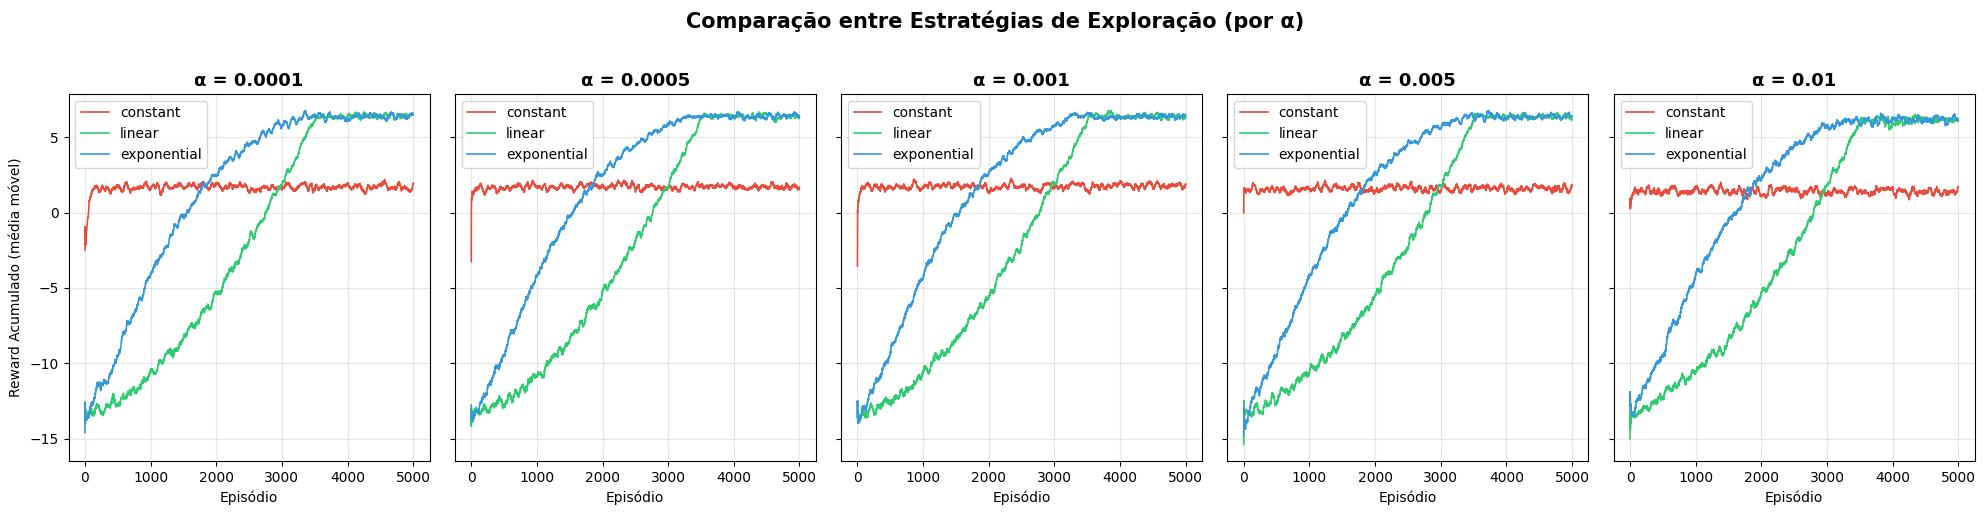

In [ ]:
fig, axes = plt.subplots(1, len(LEARNING_RATES), figsize=(20, 5), sharey=True)
decay_colors = {"constant": "#e74c3c", "linear": "#2ecc71", "exponential": "#3498db"}
line_styles = {"Q-Learning": "-", "SARSA": "--"}

for ax_idx, lr in enumerate(LEARNING_RATES):
    ax = axes[ax_idx]
    ax.set_title(f"α = {lr}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Episódio")
    if ax_idx == 0:
        ax.set_ylabel("Reward Acumulado (média móvel)")

    for agent_type in AGENT_TYPES:
        for decay_type in EPSILON_DECAY_TYPES:
            for gamma in GAMMA_VALUES:
                key = (agent_type, decay_type, lr, gamma)
                
                # Verificação de segurança
                if key not in results:
                    continue

                rewards = results[key]["metrics"]["episode_rewards"]
                smoothed = pd.Series(rewards).rolling(window=SMOOTH_WINDOW, min_periods=1).mean()
                ax.plot(
                    smoothed, 
                    label=f"{agent_type} ({decay_type})", 
                    color=decay_colors[decay_type], 
                    linestyle=line_styles[agent_type],
                    linewidth=1.5,
                    alpha=0.85
                )
    ax.legend(fontsize=8, loc='lower right', ncol=2)
    ax.grid(alpha=0.3)

fig.suptitle("Comparação entre Estratégias de Exploração (Q-Learning vs SARSA por α)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 4.3 — Evolução do Epsilon ao Longo dos Episódios

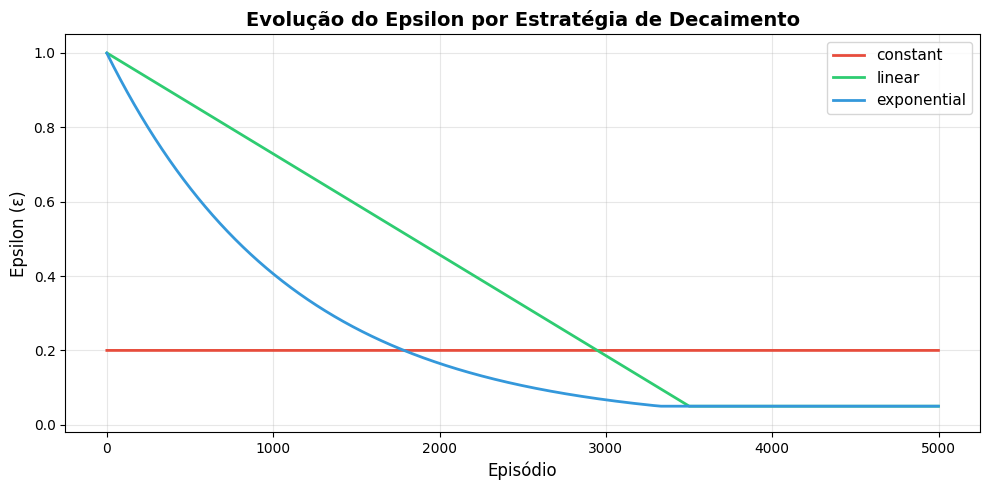

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

for decay_type in EPSILON_DECAY_TYPES:
    # Epsilon é igual para todos os LRs com o mesmo decay, usamos o primeiro
    agent_type = AGENT_TYPES[0]
    lr = LEARNING_RATES[0]
    gamma = GAMMA_VALUES[0]
    key = (agent_type, decay_type, lr, gamma)
    if key in results:
        epsilons = results[key]["metrics"]["episode_epsilons"]
        ax.plot(epsilons, label=decay_type, color=decay_colors[decay_type], linewidth=2)
    
ax.set_xlabel("Episódio", fontsize=12)
ax.set_ylabel("Epsilon (ε)", fontsize=12)
ax.set_title("Evolução do Epsilon por Estratégia de Decaimento", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_ylim(-0.02, 1.05)
plt.tight_layout()
plt.show()

### 4.4 — Reward Médio dos Últimos 100 Episódios (Heatmap)

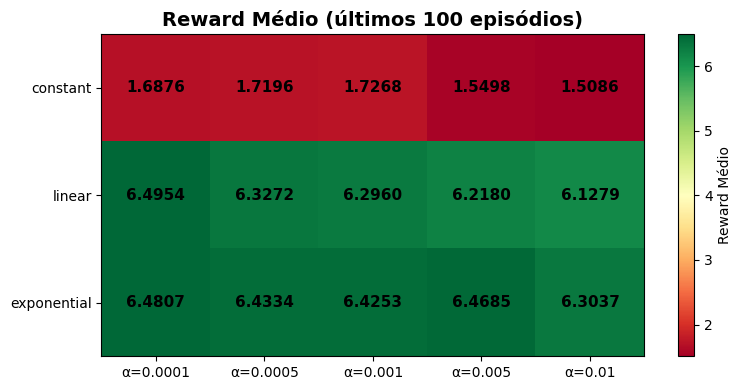

In [ ]:
# Monta matriz para o heatmap
heatmap_data = np.zeros((len(EPSILON_DECAY_TYPES), len(LEARNING_RATES)))
gamma = GAMMA_VALUES[0] # Escolha arbitrária
for i, decay_type in enumerate(EPSILON_DECAY_TYPES):
    for j, lr in enumerate(LEARNING_RATES):
        rewards = results[(decay_type, lr, gamma)]["metrics"]["episode_rewards"]
        heatmap_data[i, j] = np.mean(rewards[-100:])

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(heatmap_data, cmap="RdYlGn", aspect="auto")

ax.set_xticks(range(len(LEARNING_RATES)))
ax.set_xticklabels([f"α={lr}" for lr in LEARNING_RATES])
ax.set_yticks(range(len(EPSILON_DECAY_TYPES)))
ax.set_yticklabels(EPSILON_DECAY_TYPES)

# Anota valores
for i in range(len(EPSILON_DECAY_TYPES)):
    for j in range(len(LEARNING_RATES)):
        ax.text(j, i, f"{heatmap_data[i, j]:.4f}", ha="center", va="center", fontsize=11, fontweight="bold")

ax.set_title("Reward Médio (últimos 100 episódios)", fontsize=14, fontweight="bold")
fig.colorbar(im, ax=ax, label="Reward Médio")
plt.tight_layout()
plt.show()

### 4.5 — Q-Table da Melhor Configuração

In [ ]:
# Identifica a melhor configuração (maior reward médio nos últimos 100 eps)
best_key = max(results.keys(), key=lambda k: np.mean(results[k]["metrics"]["episode_rewards"][-100:]))
best_agent = results[best_key]["agent"]
best_reward = np.mean(results[best_key]["metrics"]["episode_rewards"][-100:])

print(f"Melhor configuração: Agente={best_key[0]} decay={best_key[1]}, α={best_key[2]}")
print(f"Reward médio (últimos 100 eps): {best_reward:.4f}")
print(f"Estados na Q-table: {len(best_agent.q_table)}")
print(f"Dimensões da Q-table: {len(best_agent.q_table.shape)}")
print()

# Exibe Q-table como DataFrame
q_df = best_agent.q_table_as_dataframe()
q_df["best_action"] = q_df[["q_sell(-1)", "q_hold(0)", "q_buy(1)"]].idxmax(axis=1)
q_df

Melhor configuração: decay=linear, α=0.0001
Reward médio (últimos 100 eps): 6.4954
Estados na Q-table: 2



,state,q_sell(-1),q_hold(0),q_buy(1),best_action
0,"(0, 0, 0, 0)",0.018581,0.018553,2.540923e-02,q_buy(1)
1,"(0, 0, 0, 1)",0.000339,0.002527,-2.447590e-04,q_hold(0)
2,"(0, 0, 1, 0)",0.012060,0.012306,-7.100494e-03,q_hold(0)
3,"(0, 0, 1, 1)",0.008131,0.010373,-3.152984e-02,q_hold(0)
4,"(0, 1, 0, 0)",0.000089,0.000068,2.979458e-04,q_buy(1)
5,"(0, 1, 0, 1)",0.000000,0.000013,-2.235627e-07,q_hold(0)
6,"(0, 1, 1, 0)",0.000092,0.000751,-2.276808e-04,q_hold(0)
7,"(0, 1, 1, 1)",0.000229,0.000022,-1.088431e-04,q_sell(-1)
8,"(1, 0, 0, 0)",0.011435,0.022251,2.308361e-02,q_buy(1)
9,"(1, 0, 0, 1)",0.001013,-0.000088,-1.842521e-04,q_sell(-1)


## 5 — Avaliação no Dataset de Teste

Avaliação greedy (sem exploração) de cada agente treinado no dataset de teste.

In [ ]:
# Avalia todos os agentes no dataset de teste
test_results = {}

for key, data in results.items():
    agent = data["agent"]
    eval_result = evaluate_agent(TEST_DATA_PATH, agent)
    test_results[key] = eval_result

# Monta tabela de resultados
rows = []
for (agent_type, decay_type, lr), eval_data in test_results.items():
    train_reward = np.mean(results[(agent_type, decay_type, lr)]["metrics"]["episode_rewards"][-100:])
    rows.append({
        "Agente":   agent_type,
        "Decay Type":       decay_type,
        "Learning Rate (α)": lr,
        "Reward Treino (últimos 100 eps)": round(train_reward, 4),
        "Reward Teste (total)":            round(eval_data["total_reward"], 4),
    })

test_df = pd.DataFrame(rows).sort_values("Reward Teste (total)", ascending=False)
test_df.reset_index(drop=True, inplace=True)
test_df

,Decay Type,Learning Rate (α),Reward Treino (últimos 100 eps),Reward Teste (total)
0,constant,0.0100,1.5086,5.2496
1,exponential,0.0001,6.4807,5.1601
2,constant,0.0001,1.6876,5.0942
3,constant,0.0050,1.5498,5.0619
4,linear,0.0100,6.1279,5.0410
5,linear,0.0010,6.2960,5.0237
6,constant,0.0010,1.7268,4.8407
7,exponential,0.0100,6.3037,4.7370
8,linear,0.0005,6.3272,4.6148
9,exponential,0.0005,6.4334,4.4383


### 5.1 — Comparação Visual: Treino vs. Teste

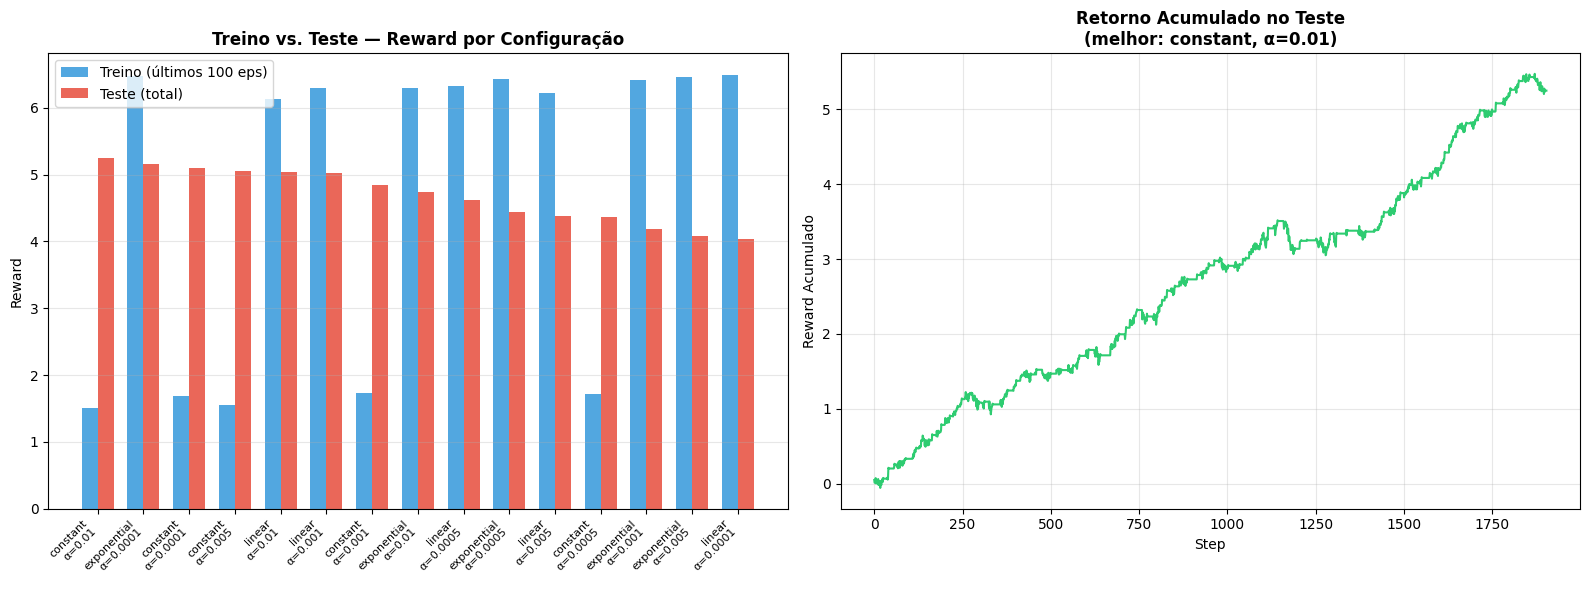

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Organiza dados para barplot
labels = [f"{d}\nα={lr}" for (d, lr) in test_df[["Agente", "Decay Type", "Learning Rate (α)"]].values]
train_vals = test_df["Reward Treino (últimos 100 eps)"].values
test_vals  = test_df["Reward Teste (total)"].values

x = np.arange(len(labels))
width = 0.35

# Barplot lado a lado
axes[0].bar(x - width/2, train_vals, width, label="Treino (últimos 100 eps)", color="#3498db", alpha=0.85)
axes[0].bar(x + width/2, test_vals,  width, label="Teste (total)",            color="#e74c3c", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=8, rotation=45, ha="right")
axes[0].set_ylabel("Reward")
axes[0].set_title("Treino vs. Teste — Reward por Configuração", fontweight="bold")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Retorno acumulado no teste da melhor configuração
best_test_key = (test_df.iloc[0]["Agente"],
                 test_df.iloc[0]["Decay Type"], 
                 test_df.iloc[0]["Learning Rate (α)"]
                )
best_step_rewards = test_results[best_test_key]["step_rewards"]
cumulative = np.cumsum(best_step_rewards)

axes[1].plot(cumulative, color="#2ecc71", linewidth=1.5)
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Reward Acumulado")
axes[1].set_title(f"Retorno Acumulado no Teste\n(melhor: {best_test_key[0]} | {best_test_key[1]}, α={best_test_key[2]})", fontweight="bold")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.2 — Trajetória do Agente (Posições no Teste)

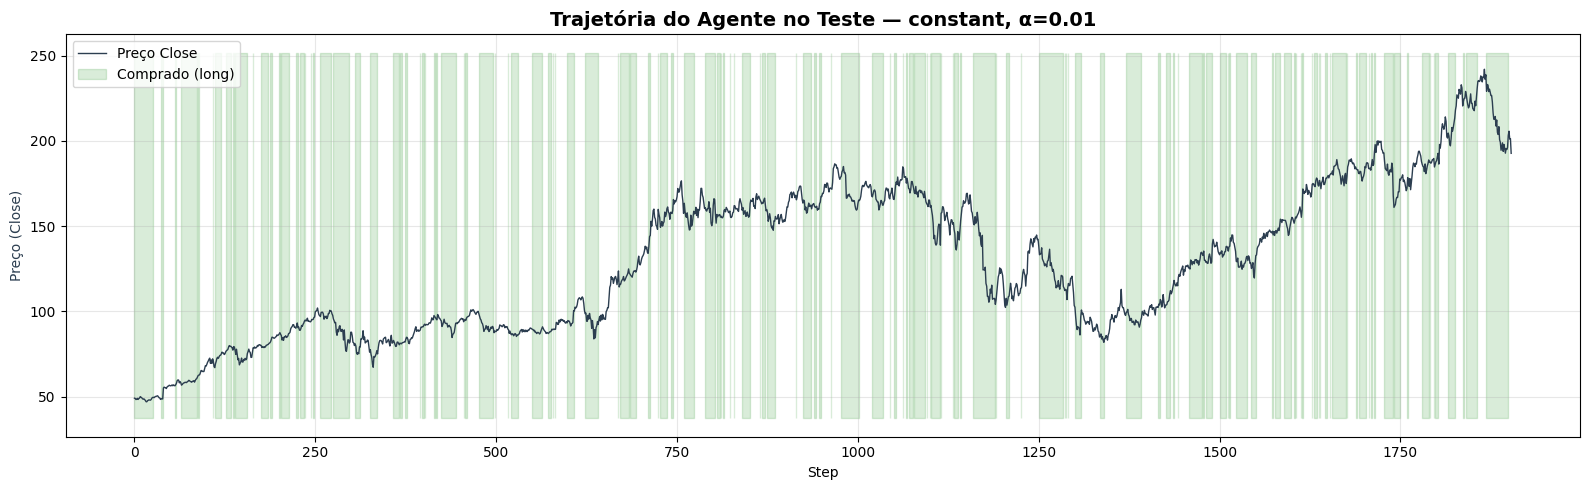

Steps comprado: 941 (49.4%)
Steps fora:     963 (50.6%)


In [ ]:
# Carrega preços de teste para visualização
test_prices = pd.read_csv(TEST_DATA_PATH)["Close"].values

best_positions = test_results[best_test_key]["positions"]

fig, ax1 = plt.subplots(figsize=(16, 5))

# Preço
ax1.plot(test_prices[1:len(best_positions)+1], color="#2c3e50", linewidth=1, label="Preço Close")
ax1.set_xlabel("Step")
ax1.set_ylabel("Preço (Close)", color="#2c3e50")

# Marca regiões onde o agente está comprado (position=1)
pos_array = np.array(best_positions)
ax1.fill_between(
    range(len(pos_array)),
    ax1.get_ylim()[0], ax1.get_ylim()[1],
    where=pos_array == 1,
    alpha=0.15, color="green", label="Comprado (long)"
)

ax1.legend(loc="upper left")
ax1.set_title(f"Trajetória do Agente no Teste — {best_test_key[0]} ({best_test_key[1]}), α={best_test_key[2]}", fontsize=14, fontweight="bold")
ax1.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Estatísticas
n_long = sum(pos_array == 1)
n_out  = sum(pos_array == 0)
print(f"Steps comprado: {n_long} ({100*n_long/len(pos_array):.1f}%)")
print(f"Steps fora:     {n_out} ({100*n_out/len(pos_array):.1f}%)")

## 6 — Salvar Resultados em CSV

In [ ]:
# Monta DataFrame com métricas de treino por episódio para todas as configurações
all_rows = []

for (agent_type, decay_type, lr), data in results.items():
    metrics = data["metrics"]
    for ep in range(len(metrics["episode_rewards"])):
        all_rows.append({
            "agent_type":      agent_type,
            "decay_type":      decay_type,
            "learning_rate":   lr,
            "episode":         ep,
            "reward":          metrics["episode_rewards"][ep],
            "epsilon":         metrics["episode_epsilons"][ep],
            "steps":           metrics["episode_steps"][ep],
        })

train_df = pd.DataFrame(all_rows)
train_df.to_csv("data/training_results.csv", index=False)
print(f"Salvo em data/training_results.csv — {len(train_df)} linhas")
train_df.head()

Salvo em data/training_results.csv — 75000 linhas


,decay_type,learning_rate,episode,reward,epsilon,steps
0,constant,0.0001,0,-2.491195,0.2,4442
1,constant,0.0001,1,-1.941235,0.2,4442
2,constant,0.0001,2,0.800703,0.2,4442
3,constant,0.0001,3,-0.123814,0.2,4442
4,constant,0.0001,4,-3.206060,0.2,4442
